# Lab 2: 10-year CHD risk by age and sex, Framingham teaching subset
Van Mont, PUBH 4201

Question: how does 10-year coronary heart disease incidence differ
across age groups, and does the gap between men and women change with age?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
df = pd.read_csv(URL)
print(df.shape)
df.head()

(4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [2]:
print(df["age"].min(), df["age"].max())
print(df[["age", "male", "TenYearCHD"]].isna().sum())

32 70
age           0
male          0
TenYearCHD    0
dtype: int64


In [3]:
# derived variable: bin continuous age into decades
df["age_group"] = pd.cut(
    df["age"],
    bins=[30, 40, 50, 60, 75],
    labels=["30-39", "40-49", "50-59", "60+"],
    right=False,
)

# aggregation: CHD incidence (%) by age group and sex
rates = (
    df.groupby(["age_group", "male"], observed=True)["TenYearCHD"]
      .mean()
      .mul(100)
      .unstack()
      .rename(columns={0: "Female", 1: "Male"})
)
rates.round(1)

male,Female,Male
age_group,,
30-39,2.3,6.3
40-49,7.8,13.0
50-59,15.7,25.3
60+,24.6,32.0


In [4]:
# denominators behind each rate: people (n) and CHD events per cell
counts = (
    df.groupby(["age_group", "male"], observed=True)["TenYearCHD"]
      .agg(n="size", events="sum")
      .unstack()
      .rename(columns={0: "Female", 1: "Male"})
)
counts

n      events     
male      Female Male Female Male
age_group                        
30-39        303  253      7   16
40-49        940  721     73   94
50-59        771  562    121  142
60+          406  284    100   91

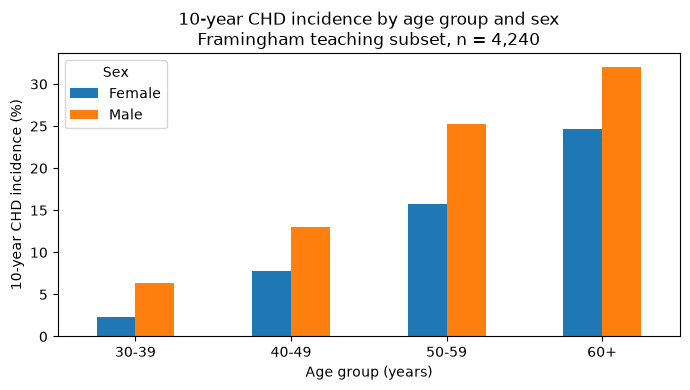

In [5]:
ax = rates.plot(kind="bar", figsize=(7, 4))
ax.set_xlabel("Age group (years)")
ax.set_ylabel("10-year CHD incidence (%)")
ax.set_title("10-year CHD incidence by age group and sex\nFramingham teaching subset, n = 4,240")
ax.legend(title="Sex")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## CHD INTERPRETATION

Ten-year CHD incidence goes up with age in both men and women, from 2.3% in women and 6.3% in men ages 30–39 to 24.6% and 32.0% in people 60 and older. Men have a higher incidence in every age group, and the difference grows from 4.0 percentage points in the youngest group to 9.6 points at ages 50–59 before dropping to 7.4 points in the oldest group. At the same time, the male-to-female ratio gets smaller with age, falling from 2.7 to 1.3, so the difference between men and women looks smaller when measured relatively. The youngest group is probably the least stable because there were so few events, especially only 7 among women, and these percentages also do not account for other risk factors like smoking, blood pressure, or cholesterol.

## AI assistance

Model: Claude Opus 5 (claude.ai), September 2026.

**Setup and debugging.** I ran the environment setup myself and used Claude as a
reference when something broke. It caught two things I would have missed: that
the `repro-lab` env I'd tried to reuse from Lab 1 was a uv-managed venv whose
`uv.lock` I'd desync by installing into it, and that my first `python3 -m venv`
had built on macOS's bundled Python 3.9 rather than the 3.12 I assumed I had.
The empty kernel picker turned out to be missing VS Code extensions, which I
found by working through its suggestions. It recommended switching this repo to
uv for the lockfile; I stayed on pip and `requirements.txt` since the setup was
already working.


**Analysis code.** Claude drafted the `pd.cut` binning and the
groupby/mean/unstack chain. I brought the question and the column names, ran the
range check that confirmed ages span 32–70 so nothing fell outside my bins, and
ran the cell counts. Two things it explained that I didn't know going in:
`pd.cut` defaults to right-closed intervals, so a 40-year-old would land in the
"30-39" bin unless you pass `right=False`; and the mean of a 0/1 column is the
incidence proportion directly, which is why `.mul(100)` gets you a percentage
without a separate count-and-divide.